In [1]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
import time
import datetime
import optax
# from parent_dir import *
from reupload_ff_circuit.data_gen import data_generator

import os
import ipynbname  

from reupload_ff_circuit.util import *
from reupload_ff_circuit.q_functions import *
from reupload_ff_circuit.q_circuits import *

/home/pjlu/anaconda3/envs/research/lib/python3.13/site-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.8.1 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


In [2]:
import gc
from reupload_ff_circuit.memory_monitor import MemoryMonitor

monitor = MemoryMonitor(threshold_mb=50)
monitor.start()


In [3]:
# Added to silence some warnings.
from jax import config
config.update("jax_enable_x64", True)
import jax
import jax.numpy as jnp
jax.config.update('jax_platform_name', 'cpu')

In [4]:
# nb_fname = ipynbname.name()
# ver = nb_fname[nb_fname.index('v'):nb_fname.index('_')] if 'v' in nb_fname else nb_fname
date, day = time.strftime("%Y%m%d-%H%M"), time.strftime("%Y%m%d-%H")
cwd = os.getcwd()

In [5]:
ver = 'Demo_v1.0'
problem = 'breast_cancer' #'3 circles'#'moon'#
shape =  "tetrahedron"#"binary" #"bitwise" #"square plane"#
rot = 'zyz' #'yzy' #'xzx' #
num_training = 200 #400
num_test = 50 #100

max_n_converge = 10
thres_converge = 0.0001
seed_num = data_seed_num= 40#

In [6]:
training_noise =  False  #True#,
test_noise = False  #True#,

In [7]:
# service = QiskitRuntimeService()
# backend = service.backend("ibm_brisbane")  # ibm_strasbourg # 
# print('backend:', backend.name)

In [8]:
configs = {'noise': False,  #####
           'fake_backend': False,    #True#,
           'real_device':  False,    #True#
           'preprocess' : "scaling",  #None #  "normalization"# "standardization" #
           # 'backend' : backend,
           'backend_name' : None, #'ibm_brisbane', # 'ibm_strasbourg', # '''None means least_busy backend'''
           'rot' : rot, 
           'shape' : shape,
          }

In [9]:
import random
num_cvs = 5
num_seeds = 10
random.seed(seed_num)
seeds = [random.randint(0, int(1e5)) for _ in range(num_seeds)]
seeds

[60110, 75954, 68678, 4174, 32150, 37018, 87104, 83505, 87073, 27044]

In [10]:
# set range of aubits and rotations
num_settings = 1, 2, 2, 1, 1 # r_enc, r_q ,r_f, r_r, r_rot ## run the setting with n values
start_values = 5, 1, 1, 1, 2 # e0, q0, f0, r0, rot0 

settings = setting_generator(num_settings,start_values)
# settings=settings[:3]

In [11]:
h_params= {'lr':[[0.15,0.05,0.01],[0.15,0.05,0.01,0.001,0.0001]],  #
           'max_epoch':[600],#3200
           'batch_size':[50,100,300],
           'dynamic_size':[50],
           'thres':[[0.05,0.03,0.01]]}#]}#[0.05],
h_pms = [(tuple(i),j,k,l,tuple(m)) for i in h_params['lr'] for j in h_params['max_epoch'] for k in h_params['batch_size'] for l in h_params['dynamic_size'] for m in h_params['thres']]
h_pms

[((0.15, 0.05, 0.01), 600, 50, 50, (0.05, 0.03, 0.01)),
 ((0.15, 0.05, 0.01), 600, 100, 50, (0.05, 0.03, 0.01)),
 ((0.15, 0.05, 0.01), 600, 300, 50, (0.05, 0.03, 0.01)),
 ((0.15, 0.05, 0.01, 0.001, 0.0001), 600, 50, 50, (0.05, 0.03, 0.01)),
 ((0.15, 0.05, 0.01, 0.001, 0.0001), 600, 100, 50, (0.05, 0.03, 0.01)),
 ((0.15, 0.05, 0.01, 0.001, 0.0001), 600, 300, 50, (0.05, 0.03, 0.01))]

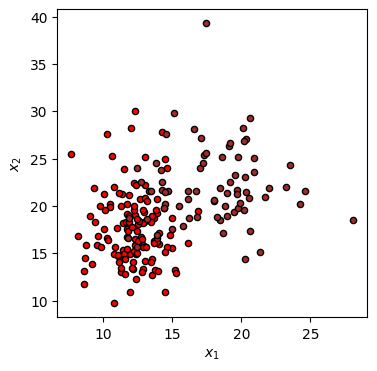

In [12]:
Xdata, ydata = data_gen(problem,num_training)
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
plot_data(Xdata, ydata, fig=fig, ax=ax)
plt.show()

theta = [0.         1.91063324 1.91063324 1.91063324] 
phi = [0.         2.0943951  4.1887902  6.28318531]
c_states= [[[ 1.        +0.00000000e+00j]
  [ 0.        +0.00000000e+00j]]

 [[ 0.57735027+0.00000000e+00j]
  [-0.40824829+7.07106781e-01j]]

 [[ 0.57735027+0.00000000e+00j]
  [-0.40824829-7.07106781e-01j]]

 [[ 0.57735027+0.00000000e+00j]
  [ 0.81649658-1.99983985e-16j]]] 
shape: (4, 2, 1)


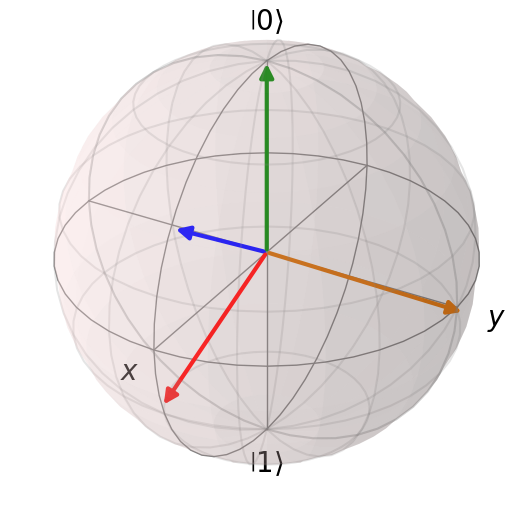

In [13]:
# Define output labels as quantum state vectors
num_class = np.unique(data_gen(problem)[1]).max()+1
c_states, dm_labels, Yc = predefined_states_dm(shape,settings[0][1]) #(shape,num_qubits)
configs['dm_labels'] = dm_labels
configs['num_class_1q'] = len(c_states)
configs['Yc'] = totuple(Yc)

In [14]:
def fit(params: optax.Params, optimizer: optax.GradientTransformation,
        opt_state,x,y,*args,x_valid=None,y_valid=None,**kwargs) -> optax.Params:
  #opt_state = optimizer.init(params)
  # for k, v in kwargs.items():
  #   if 'noise' in k:
  #       noise = v
  def step(params, opt_state,x,y):
    loss_batches = jnp.array([])
    predicted_train = jnp.array([])
    iter_batch = iterate_minibatches(x, y, batch_size=batch_size)
    for x_batch, y_batch in iter_batch:
        predicted_batch, loss_batch , grads = jtest(params, x_batch, y_batch,*args,**kwargs)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        loss_batches = jax.numpy.append(loss_batches,loss_batch)
        predicted_train = jax.numpy.append(predicted_train, predicted_batch)
    loss_value = jnp.average(loss_batches)
    return params, opt_state, loss_value, predicted_train
  n_converge = 0
  
  learning_rate,max_epoch,batch_size,dynamic_size,threshold = kwargs['_h_pm']
  iter_lr = kwargs['iter_lr']
  iter_thres = kwargs['iter_thres']
  lr = kwargs['lr']
  thres_n = kwargs['thres_n']
  

  #loss_history = []
  params_history = []
  state_history = []
  valid_accuracy_history=[]
  ave_loss = 1
  l_r = lr
  thres = thres_n
  for i  in range(max_epoch):
    i=i+1
    state_history.append(opt_state) #save value advance otherwise it saves the updated one
    params_history.append(params)
    
    params, opt_state, loss_value , predicted_train= step(params, opt_state, x, y)
    accuracy_train = accuracy_score(y, predicted_train)
    if i%100 ==0:
        print(f'step {i}, accuracy_train:{accuracy_train}, loss: {loss_value}')
        
    if x_valid is not None and y_valid is not None:
        accuracy_valid, loss_valid = scores(params, x_valid, y_valid, *args, **kwargs)
        valid_loss_history.append(float(loss_valid))
        valid_accuracy_history.append(float(accuracy_valid))
    loss_history.append(float(loss_value))    
    accuracy_history.append(float(accuracy_train))

    if i%dynamic_size==0:
        c_ave = sum(loss_history[-dynamic_size:])/dynamic_size #current loss average
        now_thres = abs(c_ave-ave_loss)/ave_loss
        print(now_thres)
        if  now_thres<=thres:
            try:
                l_r=next(iter_lr)#learning_rate
                #loc_best_accuracy = np.argmax(accuracy_history[-dynamic_size:])-dynamic_size
                loc_best_loss = np.argmin(loss_history[-dynamic_size:])-dynamic_size
                params = params_history[loc_best_loss]
                #print('best known accuracy:', accuracy_history[loc_best_accuracy]) #update lr based on accuracy
                print('accuracy of best loss :', accuracy_history[loc_best_loss]) #update lr based on loss
                
                opt_state.hyperparams['learning_rate'] = l_r
                #print('lr:', l_r, opt_state.hyperparams['learning_rate'])
                try:
                    thres = next(iter_thres)
                except StopIteration:
                    print(thres)
            except StopIteration:
                pass
        print('lr:', l_r, opt_state.hyperparams['learning_rate'])
        print(i)
        n_converge  = n_converge+1 if now_thres<thres_converge else 0
        ave_loss = c_ave
        
    if i==max_epoch or n_converge==max_n_converge:
        n_converge = 1 if n_converge==0 else n_converge 
        #loc_best_accuracy = np.argmax(accuracy_history[-dynamic_size*10:])-dynamic_size*10
        candidate_history = loss_history if x_valid is None else valid_loss_history
        loc_best_loss = np.argmin(candidate_history[-dynamic_size*n_converge:])-dynamic_size*n_converge
        params = params_history[loc_best_loss]
        opt_state = state_history[loc_best_loss]
        num_epoch = i
        print('lr:', l_r, opt_state.hyperparams['learning_rate'])
        print('accuracy of best loss:',accuracy_history[loc_best_loss],loc_best_loss)
        #print('best known accuracy:',accuracy_history[loc_best_loss],loc_best_loss)
        break
  return params, l_r, opt_state, num_epoch

In [15]:
if '-' not in ver:
    # ver = ver+f'_lay{num_layers}'
    ver = ver+'_'+configs['backend_name']+'_'+date if configs['noise'] else ver+'_'+date
#print(os.getcwd())
filename = ver[:ver.index('_')]
os.chdir(cwd)
if not os.path.exists('Figures/'+filename+'/'+day):
    if not os.path.exists('Figures/'):
        os.mkdir('Figures/')
    try:
        os.mkdir('Figures/'+filename)
        os.mkdir('Figures/'+filename+'/'+day)
        os.chdir('Figures/'+filename+'/'+day)
    except FileExistsError:
        os.mkdir('Figures/'+filename+'/'+day)
        os.chdir('Figures/'+filename+'/'+day)
    except Exception as e:
        print(e)
else: os.chdir('Figures/'+filename+'/'+day)
print(os.getcwd())

/mnt/c/Users/user/Desktop/Python/Work/Re-upload-and-feed-forward-circuits/Figures/Demo/20251222-09


In [ ]:
def n_cv(n_fold, x, y, setting, *var, seed_num=42, **kwargs):
    from sklearn.utils import shuffle
    from sklearn.model_selection import StratifiedKFold
    global loss_history,valid_loss_history, accuracy_history, loss_history_cvs 
    global iter_lr, iter_thres, lr, thres_n
    
    skf = StratifiedKFold(n_splits=5)
    enc_dim,num_qubits,num_layers,num_reupload,num_rot = setting 
    start = time.process_time()
    cv_rsts= []
    # kwargs['qc'] = qcircuit(*setting, **kwargs)
    
    for index_tr, index_te in skf.split(x, y):
        cv_xtr, cv_ytr = x[index_tr], y[index_tr]
        cv_xte, cv_yte = x[index_te], y[index_te]
        
        kwargs['iter_lr'] = iter(learning_rate)
        kwargs['iter_thres'] = iter(list(threshold))
        kwargs['lr'] = next(kwargs['iter_lr'])
        kwargs['thres_n'] = next(kwargs['iter_thres'])
        
        # initialize random weights
        params = initialize_params(enc_dim, num_qubits, num_layers, num_reupload, num_rot, kwargs['num_class_1q'], seed_num)
        optimizer = optax.inject_hyperparams(optax.adam)(learning_rate=kwargs['lr'])#optax.adam(learning_rate=0.05)
        opt_state = optimizer.init(params)

        loss_history = []
        valid_loss_history = []
        accuracy_history = []

        params, lr, opt_state, num_epoch = fit(params, optimizer, opt_state, cv_xtr, cv_ytr, x_valid=cv_xte, y_valid=cv_yte,*setting,**kwargs)
        accuracy_train, loss, accuracy_test, loss_test = scores(params, cv_xtr, cv_ytr,*setting, 
                                                                x_te=cv_xte, y_te=cv_yte, **kwargs)
        loss_history_cvs.append([loss_history,valid_loss_history])
        print("Epoch: {:2d} | Cost: {:3f} | Train accuracy: {:3f} | Test Accuracy: {:3f}".format(0, loss, accuracy_train, accuracy_test))
        print(f"(n_dim, n_q, n_f, n_r, n_rot) = {enc_dim, num_qubits, num_layers, num_reupload, num_rot}")
        cv_rsts.append([accuracy_test, loss])
        plot_loss_history(loss_history, valid_loss_history, setting=setting, fig_name=None)
        
    end = time.process_time()
    print("cv_time ：%f s" % (end - start))
    return sum(np.array(cv_rsts)[:,0])/n_fold, sum(np.array(cv_rsts)[:,1])/n_fold

: 

0.9112865633633201
lr: 0.15 0.15
50
step 100, accuracy_train:0.9, loss: 0.06799276018045296
0.23392139426765374
lr: 0.15 0.15
100
9.31810068750944e-05
accuracy of best loss : 0.9
lr: 0.05 0.05
150
step 200, accuracy_train:0.89375, loss: 0.06528561084407272
0.039734738193477906
lr: 0.05 0.05
200
0.0009252937623889075
accuracy of best loss : 0.89375
lr: 0.01 0.01
250
step 300, accuracy_train:0.89375, loss: 0.06469412072782602
0.009574005505143247
lr: 0.01 0.01
300
0.00012346551006510166
lr: 0.01 0.01
350
step 400, accuracy_train:0.89375, loss: 0.06470748166982061
0.00010262620163762252
lr: 0.01 0.01
400
8.429960789021717e-05
lr: 0.01 0.01
450
step 500, accuracy_train:0.89375, loss: 0.06471649656518356
6.930121777319838e-05
lr: 0.01 0.01
500
5.6942747020025134e-05
lr: 0.01 0.01
550
step 600, accuracy_train:0.89375, loss: 0.0647225770550292
4.673657673617436e-05
lr: 0.01 0.01
600
lr: 0.01 0.01
accuracy of best loss: 0.89375 -200
Epoch:  0 | Cost: 0.051789 | Train accuracy: 0.887500 | Test 

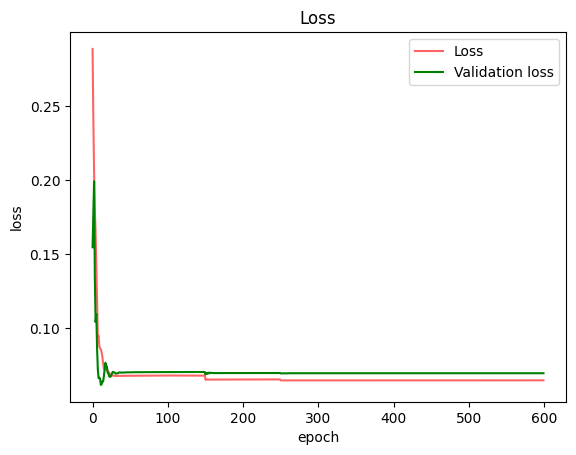

0.8276110102857751
lr: 0.15 0.15
50
step 100, accuracy_train:0.4625, loss: 0.16131376509879705
0.07081850293836406
lr: 0.15 0.15
100
0.004118699673749024
accuracy of best loss : 0.45625
lr: 0.05 0.05
150
step 200, accuracy_train:0.475, loss: 0.15678399131606943
0.024973474507582184
accuracy of best loss : 0.475
lr: 0.01 0.01
200
0.005256416579613722
lr: 0.01 0.01
250
step 300, accuracy_train:0.475, loss: 0.15586334323920892
0.0004618963409731999
lr: 0.01 0.01
300
0.0010746093649377857
lr: 0.01 0.01
350
step 400, accuracy_train:0.44375, loss: 0.15563138286613656
0.0007135440480113963
lr: 0.01 0.01
400
0.0001519377646402228
lr: 0.01 0.01
450
step 500, accuracy_train:0.44375, loss: 0.15561673307380874
4.162077568163111e-05
lr: 0.01 0.01
500
1.8122010410869602e-05
lr: 0.01 0.01
550
step 600, accuracy_train:0.44375, loss: 0.1556136975407139
9.358712202453116e-06
lr: 0.01 0.01
600
lr: 0.01 0.01
accuracy of best loss: 0.44375 -1
Epoch:  0 | Cost: 0.166664 | Train accuracy: 0.450000 | Test Acc

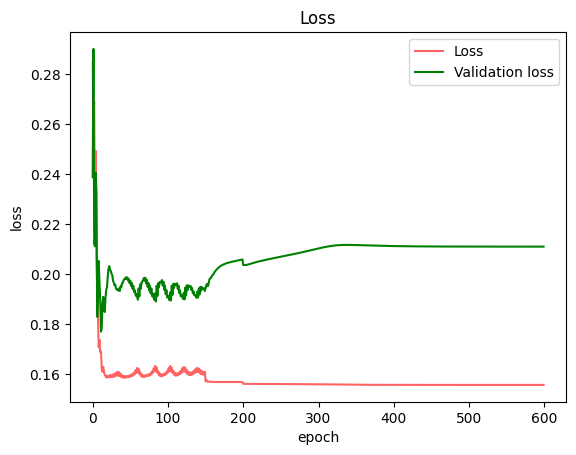

0.8892030144164789
lr: 0.15 0.15
50
step 100, accuracy_train:0.46875, loss: 0.07949033728923854
0.2796078549208742
lr: 0.15 0.15
100
0.005745369116957277
accuracy of best loss : 0.475
lr: 0.05 0.05
150
step 200, accuracy_train:0.4875, loss: 0.07737907518190129
0.02492307608359844
accuracy of best loss : 0.48125
lr: 0.01 0.01
200
0.008569210857214205
lr: 0.01 0.01
250
step 300, accuracy_train:0.4875, loss: 0.07668554599601188
0.0003122268824255255
lr: 0.01 0.01
300
0.00018670363014655628
lr: 0.01 0.01
350
step 400, accuracy_train:0.4875, loss: 0.07666867029504755
0.00010703409360913438
lr: 0.01 0.01
400
5.561159687272241e-05
lr: 0.01 0.01
450
step 500, accuracy_train:0.48125, loss: 0.07666453563225806
2.5549964424008023e-05
lr: 0.01 0.01
500
9.899814643606766e-06
lr: 0.01 0.01
550
step 600, accuracy_train:0.4875, loss: 0.07666404337836119
2.8057414244705437e-06
lr: 0.01 0.01
600
lr: 0.01 0.01
accuracy of best loss: 0.4875 -200
Epoch:  0 | Cost: 0.078336 | Train accuracy: 0.487500 | Test

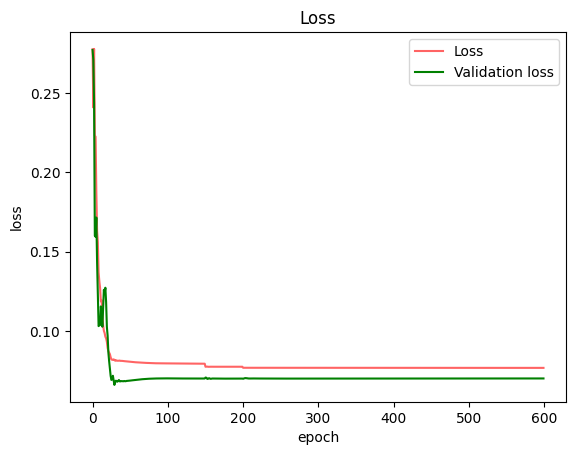

0.860026436979776
lr: 0.15 0.15
50
step 100, accuracy_train:0.44375, loss: 0.11748430445740643
0.16155048134756608
lr: 0.15 0.15
100
0.00336533231088743
accuracy of best loss : 0.45
lr: 0.05 0.05
150
step 200, accuracy_train:0.4625, loss: 0.11516256313765352
0.0219886466970295
accuracy of best loss : 0.4625
lr: 0.01 0.01
200
0.005404343649446083
lr: 0.01 0.01
250
step 300, accuracy_train:0.4625, loss: 0.11454970570137074
3.020090692588455e-05
lr: 0.01 0.01
300
3.7535724766338415e-05
lr: 0.01 0.01
350
step 400, accuracy_train:0.4625, loss: 0.11455704028419902
3.192500334936042e-05
lr: 0.01 0.01
400
2.6596033501120048e-05
lr: 0.01 0.01
450
step 500, accuracy_train:0.4625, loss: 0.11456211405326475
2.2038513633795203e-05
lr: 0.01 0.01
500
1.8249269050436943e-05
lr: 0.01 0.01
550
step 600, accuracy_train:0.4625, loss: 0.1145655927872507
1.5109803162846718e-05
lr: 0.01 0.01
600
lr: 0.01 0.01
accuracy of best loss: 0.4625 -136
Epoch:  0 | Cost: 0.130296 | Train accuracy: 0.462500 | Test Accu

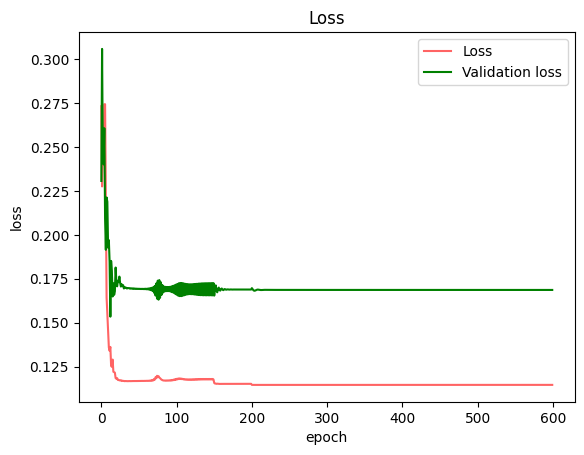

0.9362929398153503
lr: 0.15 0.15
50
step 100, accuracy_train:0.7125, loss: 0.050878391921719716
0.19805946935744587
lr: 0.15 0.15
100
0.010224875592929035
accuracy of best loss : 0.75625
lr: 0.05 0.05
150
step 200, accuracy_train:0.73125, loss: 0.048765744800017025
0.05508401789560184
lr: 0.05 0.05
200
0.000514741955274672
accuracy of best loss : 0.73125
lr: 0.01 0.01
250
step 300, accuracy_train:0.73125, loss: 0.048351980909786776
0.009032295928429048
lr: 0.01 0.01
300
4.4982084302889225e-05
lr: 0.01 0.01
350
step 400, accuracy_train:0.73125, loss: 0.0483635880889344
0.00011979158938708698
lr: 0.01 0.01
400
0.00010235148975361003
lr: 0.01 0.01
450
step 500, accuracy_train:0.73125, loss: 0.04837201785366606
8.681880245725292e-05
lr: 0.01 0.01
500
7.344063321134862e-05
lr: 0.01 0.01
550
step 600, accuracy_train:0.73125, loss: 0.04837804093251157
6.201089478192084e-05
lr: 0.01 0.01
600
lr: 0.01 0.01
accuracy of best loss: 0.73125 -150
Epoch:  0 | Cost: 0.050005 | Train accuracy: 0.725000

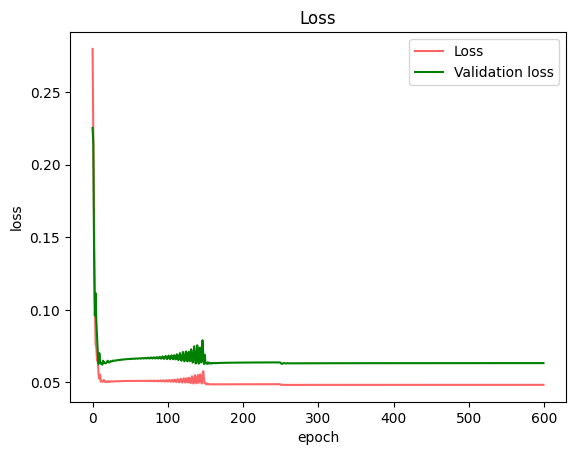

cv_time ：217.171594 s
((0.15, 0.05, 0.01), 600, 50, 50, (0.05, 0.03, 0.01))
0.9174572774242409
lr: 0.15 0.15
50
step 100, accuracy_train:0.875, loss: 0.053468162719613806
0.35879744883783204
lr: 0.15 0.15
100
0.0019477961455108624
accuracy of best loss : 0.89375
lr: 0.05 0.05
150
step 200, accuracy_train:0.8875, loss: 0.051685317483535935
0.021255959715736357
accuracy of best loss : 0.88125
lr: 0.01 0.01
200
0.0011232734586941464
lr: 0.01 0.01
250
step 300, accuracy_train:0.8875, loss: 0.051642983134837964
5.94440702691844e-08
lr: 0.01 0.01
300
1.4353449724909122e-05
lr: 0.01 0.01
350
step 400, accuracy_train:0.8875, loss: 0.051644433219188365
1.4092037482139242e-05
lr: 0.01 0.01
400
1.28068958231276e-05
lr: 0.01 0.01
450
step 500, accuracy_train:0.8875, loss: 0.051645628680217784
1.1547107603868539e-05
lr: 0.01 0.01
500
1.045777309566163e-05
lr: 0.01 0.01
550
step 600, accuracy_train:0.8875, loss: 0.051646614459069255
9.524375209056798e-06
lr: 0.01 0.01
600
lr: 0.01 0.01
accuracy of b

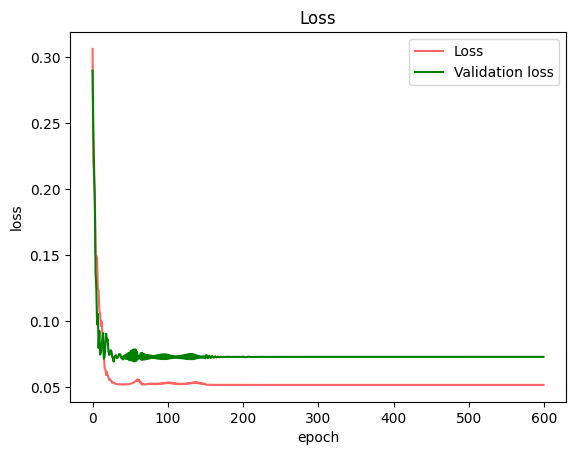

0.8638652213318074
lr: 0.15 0.15
50
step 100, accuracy_train:0.4625, loss: 0.1167320420865299
0.14284886711633255
lr: 0.15 0.15
100
0.0006250874928731314
accuracy of best loss : 0.4625
lr: 0.05 0.05
150
step 200, accuracy_train:0.45, loss: 0.11624934940046397
0.004398227079698115
accuracy of best loss : 0.45
lr: 0.01 0.01
200
0.0014342992654736754
lr: 0.01 0.01
250
step 300, accuracy_train:0.45, loss: 0.11608285287316214
1.1613679676295728e-05
lr: 0.01 0.01
300
1.286593967980075e-05
lr: 0.01 0.01
350
step 400, accuracy_train:0.45, loss: 0.11608544608061093
1.11352713687744e-05
lr: 0.01 0.01
400
9.44883573540006e-06
lr: 0.01 0.01
450
step 500, accuracy_train:0.45, loss: 0.11608733077559283
8.08299138083356e-06
lr: 0.01 0.01
500
6.986782484345785e-06
lr: 0.01 0.01
550
step 600, accuracy_train:0.45, loss: 0.11608875003413976
6.092165108839495e-06
lr: 0.01 0.01
600
lr: 0.01 0.01
accuracy of best loss: 0.45 -349
Epoch:  0 | Cost: 0.116896 | Train accuracy: 0.450000 | Test Accuracy: 0.500000

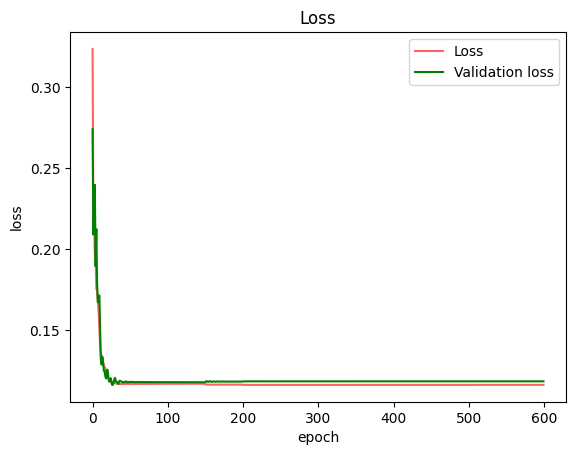

0.8865100447465779
lr: 0.15 0.15
50
step 100, accuracy_train:0.73125, loss: 0.09232775120421968
0.18691287494999517
lr: 0.15 0.15
100
0.0009369072252391532
accuracy of best loss : 0.73125
lr: 0.05 0.05
150
step 200, accuracy_train:0.7375, loss: 0.09195908771183399
0.004407720634475337
accuracy of best loss : 0.7375
lr: 0.01 0.01
200
0.001490349289315006
lr: 0.01 0.01
250
step 300, accuracy_train:0.7375, loss: 0.09181855215844595
1.693504983637093e-05
lr: 0.01 0.01
300
1.3701680382819649e-05
lr: 0.01 0.01
350
step 400, accuracy_train:0.7375, loss: 0.0918208994042427
1.2740941138521497e-05
lr: 0.01 0.01
400
1.0748376141787304e-05
lr: 0.01 0.01
450
step 500, accuracy_train:0.7375, loss: 0.09182258951822855
9.165269812285527e-06
lr: 0.01 0.01
500
7.873072348980667e-06
lr: 0.01 0.01
550
step 600, accuracy_train:0.7375, loss: 0.09182384452374089
6.808908733423725e-06
lr: 0.01 0.01
600
lr: 0.01 0.01
accuracy of best loss: 0.7375 -350
Epoch:  0 | Cost: 0.092259 | Train accuracy: 0.737500 | Tes

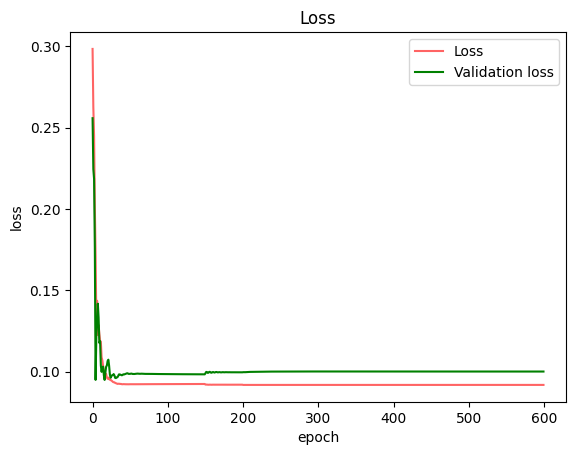

0.8353154262907037
lr: 0.15 0.15
50
step 100, accuracy_train:0.16875, loss: 0.15351596573936221
0.06818557810415057
lr: 0.15 0.15
100
0.0006658385375894393
accuracy of best loss : 0.16875
lr: 0.05 0.05
150
step 200, accuracy_train:0.16875, loss: 0.15270939647463994
0.005537021017968378
accuracy of best loss : 0.16875
lr: 0.01 0.01
200
0.0019323811057120966
lr: 0.01 0.01
250
step 300, accuracy_train:0.16875, loss: 0.15241423687990177
6.471365528563601e-06
lr: 0.01 0.01
300
1.1872612666865136e-05
lr: 0.01 0.01
350
step 400, accuracy_train:0.16875, loss: 0.15241720064794106
9.658198846930605e-06
lr: 0.01 0.01
400
8.037945425830313e-06
lr: 0.01 0.01
450
step 500, accuracy_train:0.16875, loss: 0.1524192803824554
6.789987658805335e-06
lr: 0.01 0.01
500
5.8023817873482676e-06
lr: 0.01 0.01
550
step 600, accuracy_train:0.16875, loss: 0.1524208115571769
5.003942550048498e-06
lr: 0.01 0.01
600
lr: 0.01 0.01
accuracy of best loss: 0.16875 -1
Epoch:  0 | Cost: 0.149512 | Train accuracy: 0.168750 |

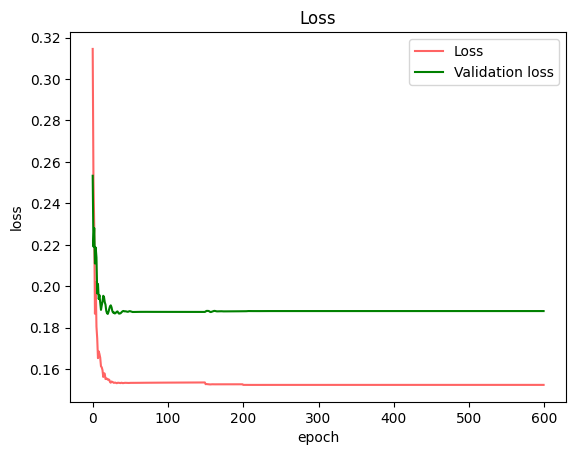

0.8992872607728238
lr: 0.15 0.15
50
step 100, accuracy_train:0.8625, loss: 0.05149863969325531
0.48703452048603874
lr: 0.15 0.15
100
0.002678043338154018
accuracy of best loss : 0.8625
lr: 0.05 0.05
150
step 200, accuracy_train:0.86875, loss: 0.05092507867308206
0.011630683308527187
accuracy of best loss : 0.86875
lr: 0.01 0.01
200
0.0033718167690099175
lr: 0.01 0.01
250
step 300, accuracy_train:0.86875, loss: 0.05075478397577735
2.3583656864379954e-05
lr: 0.01 0.01
300
2.8150593750847605e-05
lr: 0.01 0.01
350
step 400, accuracy_train:0.86875, loss: 0.050757168057294716
2.3351551433008018e-05
lr: 0.01 0.01
400
1.97097911234511e-05
lr: 0.01 0.01
450
step 500, accuracy_train:0.86875, loss: 0.050758883912847635
1.6830212737536934e-05
lr: 0.01 0.01
500
1.4512963810284035e-05
lr: 0.01 0.01
550
step 600, accuracy_train:0.86875, loss: 0.05076017023583074
1.262595959069767e-05
lr: 0.01 0.01
600
lr: 0.01 0.01
accuracy of best loss: 0.86875 -1
Epoch:  0 | Cost: 0.050996 | Train accuracy: 0.86875

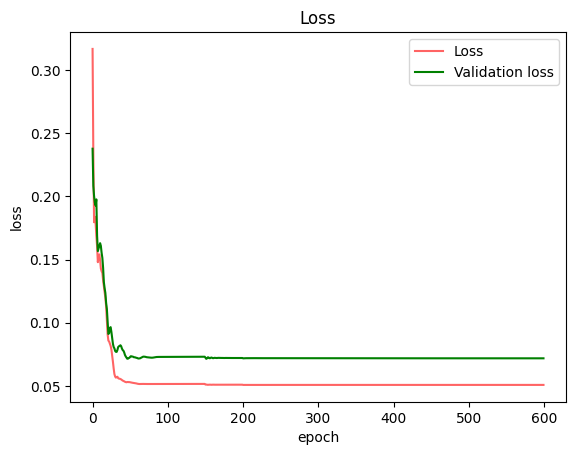

cv_time ：239.232199 s
((0.15, 0.05, 0.01), 600, 100, 50, (0.05, 0.03, 0.01))
0.8947493782529365
lr: 0.15 0.15
50
step 100, accuracy_train:0.875, loss: 0.050594195557656964
0.5127748581774811
lr: 0.15 0.15
100
0.01372159163202376
accuracy of best loss : 0.88125
lr: 0.05 0.05
150
step 200, accuracy_train:0.88125, loss: 0.05057370112862103
6.685534253264837e-05
accuracy of best loss : 0.88125
lr: 0.01 0.01
200
2.685482009942472e-07
lr: 0.01 0.01
250
step 300, accuracy_train:0.88125, loss: 0.0505737003525125
5.228537306152959e-09
lr: 0.01 0.01
300
2.0877221258675484e-09
lr: 0.01 0.01
350
step 400, accuracy_train:0.88125, loss: 0.05057370023681097
1.1015657448888972e-09
lr: 0.01 0.01
400
5.374436643370822e-10
lr: 0.01 0.01
450
step 500, accuracy_train:0.88125, loss: 0.0505737002108042
2.425445510315451e-10
lr: 0.01 0.01
500
1.014742757949858e-10
lr: 0.01 0.01
550
step 600, accuracy_train:0.88125, loss: 0.050573700206482754
3.94096770110567e-11
lr: 0.01 0.01
600
lr: 0.01 0.05
accuracy of bes

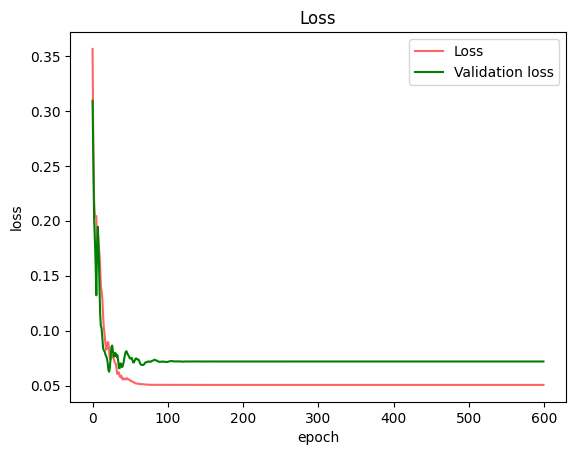

0.8306178075296091
lr: 0.15 0.15
50
step 100, accuracy_train:0.25, loss: 0.06288222784571036
0.5364033398813237
lr: 0.15 0.15
100
0.16678334722973645
lr: 0.15 0.15
150
step 200, accuracy_train:0.025, loss: 0.04518318880928553
0.1309777632295639
lr: 0.15 0.15
200
0.15317382704613886
lr: 0.15 0.15
250
step 300, accuracy_train:0.0125, loss: 0.04321392793307935
0.04092288501645436
accuracy of best loss : 0.0125
lr: 0.05 0.05
300
0.0723175997484215
lr: 0.05 0.05
350
step 400, accuracy_train:0.0, loss: 0.0418856123814916
0.0153792748110806
accuracy of best loss : 0.0
lr: 0.01 0.01
400
0.008416698206608132
lr: 0.01 0.01
450
step 500, accuracy_train:0.0, loss: 0.04163313424488118
0.0030479610540649193
lr: 0.01 0.01
500
0.003244117451208541
lr: 0.01 0.01
550
step 600, accuracy_train:0.0, loss: 0.04134704410007534
0.0034433688320477896
lr: 0.01 0.01
600
lr: 0.01 0.01
accuracy of best loss: 0.0 -1
Epoch:  0 | Cost: 0.041347 | Train accuracy: 0.000000 | Test Accuracy: 0.000000
(n_dim, n_q, n_f, n_

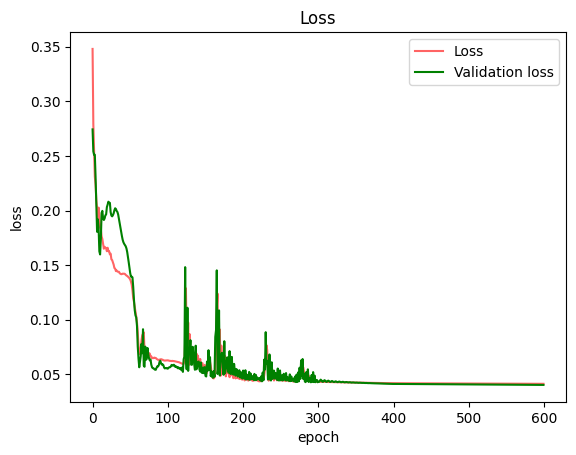

0.8960112132212004
lr: 0.15 0.15
50
step 100, accuracy_train:0.8625, loss: 0.0583278944282164
0.4354405343240913
lr: 0.15 0.15
100
0.006661696120691862
accuracy of best loss : 0.86875
lr: 0.05 0.05
150
step 200, accuracy_train:0.86875, loss: 0.05831409392924019
4.558465405100499e-05
accuracy of best loss : 0.86875
lr: 0.01 0.01
200
1.4263409930646025e-07
lr: 0.01 0.01
250
step 300, accuracy_train:0.86875, loss: 0.058314092314193225
1.2738867579525974e-08
lr: 0.01 0.01
300
9.313436337457263e-09
lr: 0.01 0.01
350
step 400, accuracy_train:0.86875, loss: 0.05831409152429812
6.706712023575677e-09
lr: 0.01 0.01
400
4.596360408741773e-09
lr: 0.01 0.01
450
step 500, accuracy_train:0.86875, loss: 0.058314091167439845
3.007271851464846e-09
lr: 0.01 0.01
500
1.882680061983979e-09
lr: 0.01 0.01
550
step 600, accuracy_train:0.86875, loss: 0.058314091032345486
1.129535787545722e-09
lr: 0.01 0.01
600
lr: 0.01 0.05
accuracy of best loss: 0.86875 -447
Epoch:  0 | Cost: 0.058314 | Train accuracy: 0.8687

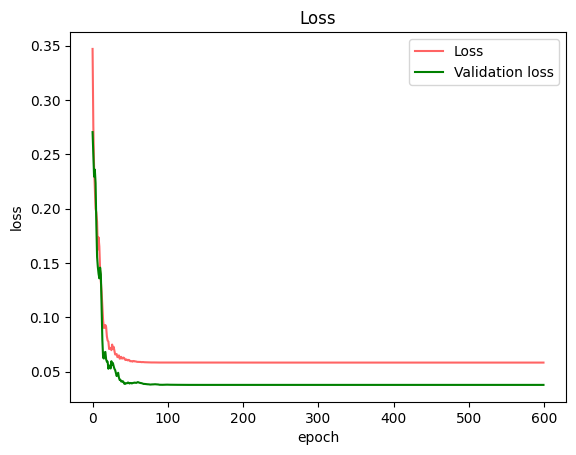

0.8488426886414375
lr: 0.15 0.15
50
step 100, accuracy_train:0.65625, loss: 0.04999272546022388
0.6484996927160792
lr: 0.15 0.15
100
0.06804579062943121
lr: 0.15 0.15
150
step 200, accuracy_train:0.59375, loss: 0.049387836706077715
0.014192102826605109
accuracy of best loss : 0.59375
lr: 0.05 0.05
200
0.016623989940946174
accuracy of best loss : 0.59375
lr: 0.01 0.01
250
step 300, accuracy_train:0.59375, loss: 0.049382879693112725
2.9193305537667937e-05
lr: 0.01 0.01
300
7.25594498966939e-07
lr: 0.01 0.01
350
step 400, accuracy_train:0.59375, loss: 0.04938283645658523
4.2865723250570513e-07
lr: 0.01 0.01
400
2.543475017584242e-07
lr: 0.01 0.01
450
step 500, accuracy_train:0.59375, loss: 0.04938282190568782
1.427398443555498e-07
lr: 0.01 0.01
500
7.587337281487156e-08
lr: 0.01 0.01
550
step 600, accuracy_train:0.59375, loss: 0.049382817958058364
3.824859126324997e-08
lr: 0.01 0.01
600
lr: 0.01 0.01
accuracy of best loss: 0.59375 -350
Epoch:  0 | Cost: 0.049383 | Train accuracy: 0.593750

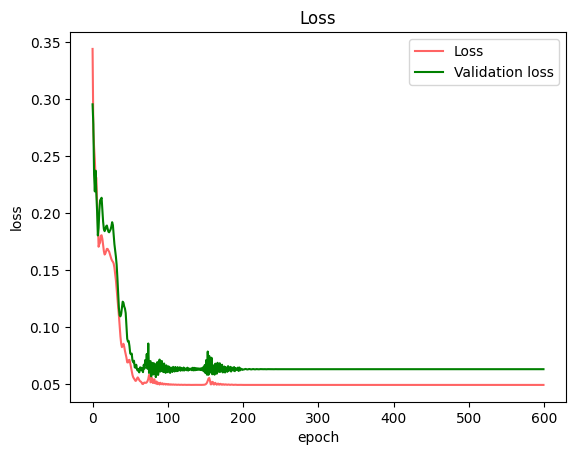

0.8250895329464971
lr: 0.15 0.15
50
step 100, accuracy_train:0.1375, loss: 0.1590641901857961
0.09014585955053507
lr: 0.15 0.15
100
0.0005064158035736532
accuracy of best loss : 0.1375
lr: 0.05 0.05
150
step 200, accuracy_train:0.1375, loss: 0.15906186921831303
2.8432140633513417e-06
accuracy of best loss : 0.1375
lr: 0.01 0.01
200
6.441276541938262e-07
lr: 0.01 0.01
250
step 300, accuracy_train:0.1375, loss: 0.15906186524687083
1.0508079060831941e-09
lr: 0.01 0.01
300
8.315407331130726e-12
lr: 0.01 0.01
350
step 400, accuracy_train:0.1375, loss: 0.15906186524667076
4.557821788117276e-13
lr: 0.01 0.01
400
8.567727787008432e-14
lr: 0.01 0.01
450
step 500, accuracy_train:0.1375, loss: 0.15906186524666482
1.448312436500531e-14
lr: 0.01 0.01
500
1.9194502170489246e-15
lr: 0.01 0.01
550
step 600, accuracy_train:0.1375, loss: 0.15906186524666466
3.4899094855435057e-16
lr: 0.01 0.01
600
lr: 0.01 0.05
accuracy of best loss: 0.1375 -447
Epoch:  0 | Cost: 0.159062 | Train accuracy: 0.137500 | Te

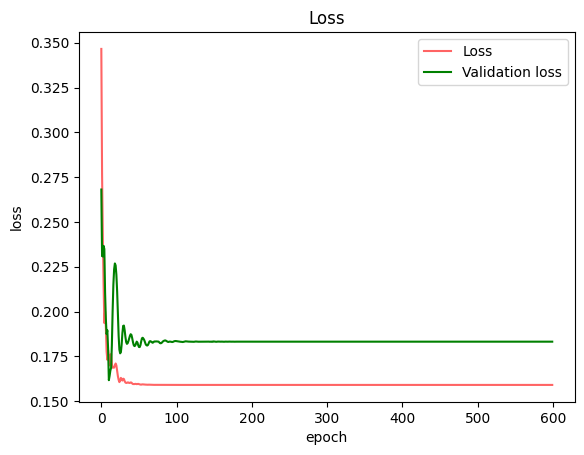

cv_time ：133.278808 s
((0.15, 0.05, 0.01), 600, 300, 50, (0.05, 0.03, 0.01))
0.9112865633633201
lr: 0.15 0.15
50
step 100, accuracy_train:0.9, loss: 0.06799276018045296
0.23392139426765374
lr: 0.15 0.15
100
9.31810068750944e-05
accuracy of best loss : 0.9
lr: 0.05 0.05
150
step 200, accuracy_train:0.89375, loss: 0.06528561084407272
0.039734738193477906
lr: 0.05 0.05
200
0.0009252937623889075
accuracy of best loss : 0.89375
lr: 0.01 0.01
250
step 300, accuracy_train:0.89375, loss: 0.06469412072782602
0.009574005505143247
accuracy of best loss : 0.9
0.01
lr: 0.001 0.001
300
0.0018317118716954877
accuracy of best loss : 0.9
0.01
lr: 0.0001 0.0001
350
step 400, accuracy_train:0.9, loss: 0.06455643913281989
0.0002321619427601008
lr: 0.0001 0.0001
400
2.507157246934749e-06
lr: 0.0001 0.0001
450
step 500, accuracy_train:0.9, loss: 0.06455613840281836
2.329478768736785e-06
lr: 0.0001 0.0001
500
2.1157878255951473e-06
lr: 0.0001 0.0001
550
step 600, accuracy_train:0.9, loss: 0.06455589112806276

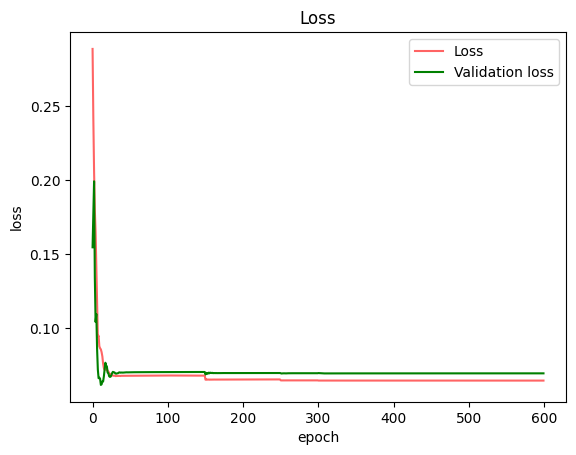

0.8276110102857751
lr: 0.15 0.15
50
step 100, accuracy_train:0.4625, loss: 0.16131376509879705
0.07081850293836406
lr: 0.15 0.15
100
0.004118699673749024
accuracy of best loss : 0.45625
lr: 0.05 0.05
150
step 200, accuracy_train:0.475, loss: 0.15678399131606943
0.024973474507582184
accuracy of best loss : 0.475
lr: 0.01 0.01
200
0.005256416579613722
accuracy of best loss : 0.475
0.01
lr: 0.001 0.001
250
step 300, accuracy_train:0.475, loss: 0.1557795785234512
0.0013787645725625952
accuracy of best loss : 0.475
0.01
lr: 0.0001 0.0001
300
0.00015137157831932762
lr: 0.0001 0.0001
350
step 400, accuracy_train:0.475, loss: 0.15575910445537447
6.619512579881287e-06
lr: 0.0001 0.0001
400
6.881236391490345e-06
lr: 0.0001 0.0001
450
step 500, accuracy_train:0.475, loss: 0.15575688136255214
7.139321221978365e-06
lr: 0.0001 0.0001
500
7.392468068416304e-06
lr: 0.0001 0.0001
550
step 600, accuracy_train:0.475, loss: 0.1557545026791286
7.639002430167935e-06
lr: 0.0001 0.0001
600
lr: 0.0001 0.0001
a

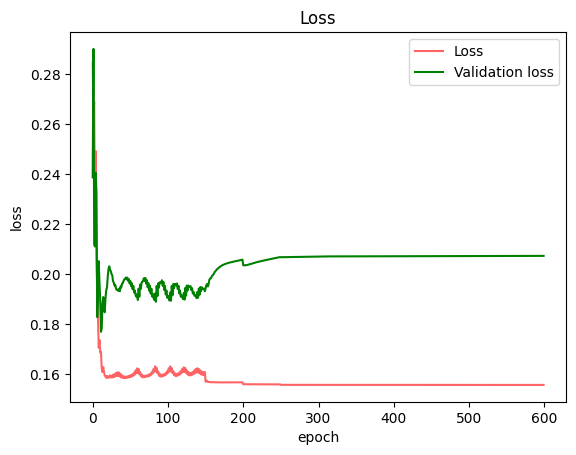

0.8892030144164789
lr: 0.15 0.15
50
step 100, accuracy_train:0.46875, loss: 0.07949033728923854
0.2796078549208742
lr: 0.15 0.15
100
0.005745369116957277
accuracy of best loss : 0.475
lr: 0.05 0.05
150
step 200, accuracy_train:0.4875, loss: 0.07737907518190129
0.02492307608359844
accuracy of best loss : 0.48125
lr: 0.01 0.01
200
0.008569210857214205
accuracy of best loss : 0.4875
0.01
lr: 0.001 0.001
250
step 300, accuracy_train:0.4875, loss: 0.07655102483301106
0.00215294829258712
accuracy of best loss : 0.4875
0.01
lr: 0.0001 0.0001
300
0.0002208211461407947
lr: 0.0001 0.0001
350
step 400, accuracy_train:0.4875, loss: 0.07653512230431464
4.677583705756837e-06
lr: 0.0001 0.0001
400
5.2130716707587484e-06
lr: 0.0001 0.0001
450
step 500, accuracy_train:0.4875, loss: 0.0765342450624522
5.737098830202543e-06
lr: 0.0001 0.0001
500
6.249946422642231e-06
lr: 0.0001 0.0001
550
step 600, accuracy_train:0.4875, loss: 0.07653321266415421
6.750848534334337e-06
lr: 0.0001 0.0001
600
lr: 0.0001 0.0

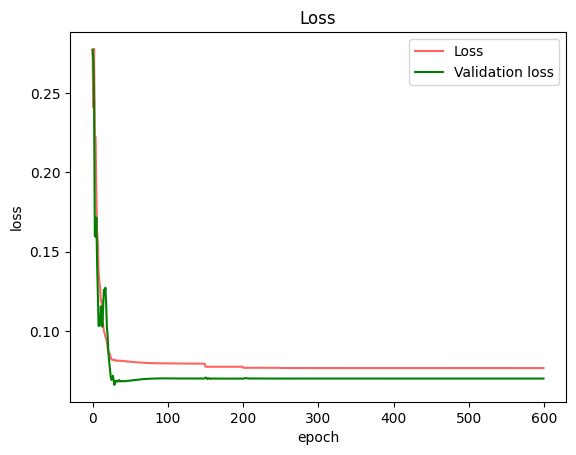

0.860026436979776
lr: 0.15 0.15
50
step 100, accuracy_train:0.44375, loss: 0.11748430445740643
0.16155048134756608
lr: 0.15 0.15
100
0.00336533231088743
accuracy of best loss : 0.45
lr: 0.05 0.05
150
step 200, accuracy_train:0.4625, loss: 0.11516256313765352
0.0219886466970295
accuracy of best loss : 0.4625
lr: 0.01 0.01
200
0.005404343649446083
accuracy of best loss : 0.4625
0.01
lr: 0.001 0.001
250
step 300, accuracy_train:0.4625, loss: 0.11441020400019479
0.0011573234505160182
accuracy of best loss : 0.4625
0.01
lr: 0.0001 0.0001
300
0.00013341652712529602
lr: 0.0001 0.0001
350
step 400, accuracy_train:0.4625, loss: 0.11439617644401348
1.8184017719437127e-07
lr: 0.0001 0.0001
400
1.885843745496763e-07
lr: 0.0001 0.0001
450
step 500, accuracy_train:0.4625, loss: 0.1143961306394215
2.0022284132040108e-07
lr: 0.0001 0.0001
500
2.1322076980444552e-07
lr: 0.0001 0.0001
550
step 600, accuracy_train:0.4625, loss: 0.11439607895262187
2.2612660598997947e-07
lr: 0.0001 0.0001
600
lr: 0.0001 0

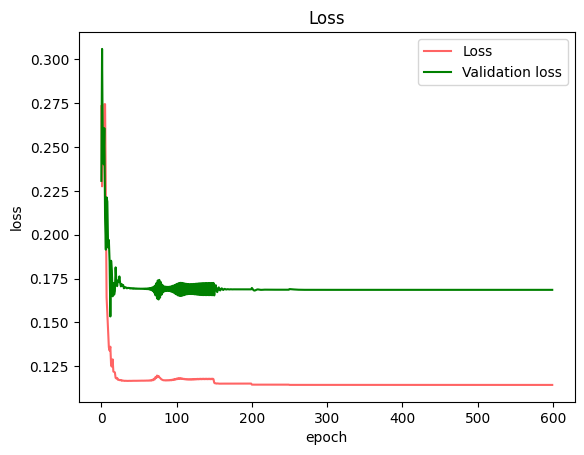

0.9362929398153503
lr: 0.15 0.15
50
step 100, accuracy_train:0.7125, loss: 0.050878391921719716
0.19805946935744587
lr: 0.15 0.15
100
0.010224875592929035
accuracy of best loss : 0.75625
lr: 0.05 0.05
150
step 200, accuracy_train:0.73125, loss: 0.048765744800017025
0.05508401789560184
lr: 0.05 0.05
200
0.000514741955274672
accuracy of best loss : 0.73125
lr: 0.01 0.01
250
step 300, accuracy_train:0.73125, loss: 0.048351980909786776
0.009032295928429048
accuracy of best loss : 0.73125
0.01
lr: 0.001 0.001
300
0.0018404429978466942
accuracy of best loss : 0.73125
0.01
lr: 0.0001 0.0001
350
step 400, accuracy_train:0.73125, loss: 0.04825563388354774
0.00016958515422378152
lr: 0.0001 0.0001
400
7.326865875036943e-06
lr: 0.0001 0.0001
450
step 500, accuracy_train:0.73125, loss: 0.04825529462562955
3.546488652657709e-06
lr: 0.0001 0.0001
500
2.4571081864160126e-06
lr: 0.0001 0.0001
550
step 600, accuracy_train:0.73125, loss: 0.048255130256510126
1.6717123265476956e-06
lr: 0.0001 0.0001
600
l

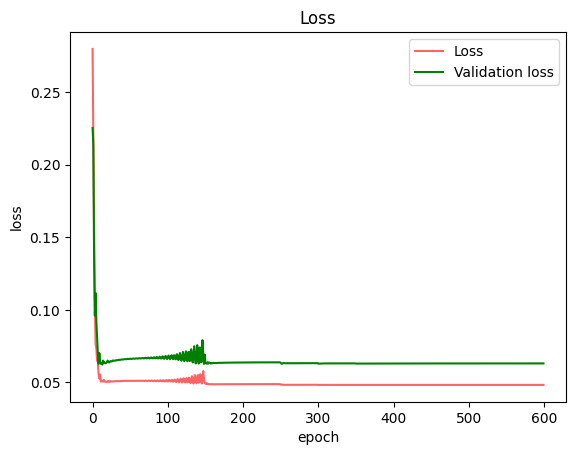

cv_time ：223.144804 s
((0.15, 0.05, 0.01, 0.001, 0.0001), 600, 50, 50, (0.05, 0.03, 0.01))
0.9174572774242409
lr: 0.15 0.15
50
step 100, accuracy_train:0.875, loss: 0.053468162719613806
0.35879744883783204
lr: 0.15 0.15
100
0.0019477961455108624
accuracy of best loss : 0.89375
lr: 0.05 0.05
150
step 200, accuracy_train:0.8875, loss: 0.051685317483535935
0.021255959715736357
accuracy of best loss : 0.88125
lr: 0.01 0.01
200
0.0011232734586941464
accuracy of best loss : 0.8875
0.01
lr: 0.001 0.001
250
step 300, accuracy_train:0.8875, loss: 0.05163277734405765
0.00018798348800882
accuracy of best loss : 0.8875
0.01
lr: 0.0001 0.0001
300
2.377168440478338e-05
lr: 0.0001 0.0001
350
step 400, accuracy_train:0.8875, loss: 0.05163167246648154
2.2485426731018738e-07
lr: 0.0001 0.0001
400
2.519801670277396e-07
lr: 0.0001 0.0001
450
step 500, accuracy_train:0.8875, loss: 0.051631643322304244
2.827576172077488e-07
lr: 0.0001 0.0001
500
3.114367455310582e-07
lr: 0.0001 0.0001
550
step 600, accuracy

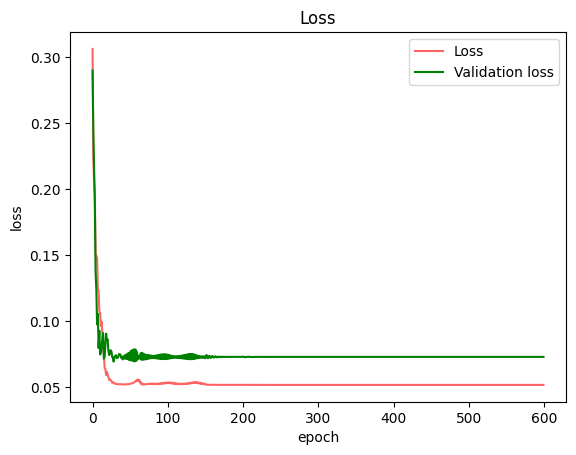

0.8638652213318074
lr: 0.15 0.15
50
step 100, accuracy_train:0.4625, loss: 0.1167320420865299
0.14284886711633255
lr: 0.15 0.15
100
0.0006250874928731314
accuracy of best loss : 0.4625
lr: 0.05 0.05
150
step 200, accuracy_train:0.45, loss: 0.11624934940046397
0.004398227079698115
accuracy of best loss : 0.45
lr: 0.01 0.01
200
0.0014342992654736754
accuracy of best loss : 0.45
0.01
lr: 0.001 0.001
250
step 300, accuracy_train:0.45, loss: 0.11604776724270671
0.00026840141652602833
accuracy of best loss : 0.45
0.01
lr: 0.0001 0.0001
300
4.717250812110267e-05
lr: 0.0001 0.0001
350
step 400, accuracy_train:0.45, loss: 0.11604377646724806
1.9806866508447506e-06
lr: 0.0001 0.0001
400
1.8552949846775119e-06
lr: 0.0001 0.0001
450
step 500, accuracy_train:0.45, loss: 0.1160433751042651
1.7282319540591323e-06
lr: 0.0001 0.0001
500
1.6003813831587309e-06
lr: 0.0001 0.0001
550
step 600, accuracy_train:0.45, loss: 0.11604303301902331
1.4724543866723642e-06
lr: 0.0001 0.0001
600
lr: 0.0001 0.0001
acc

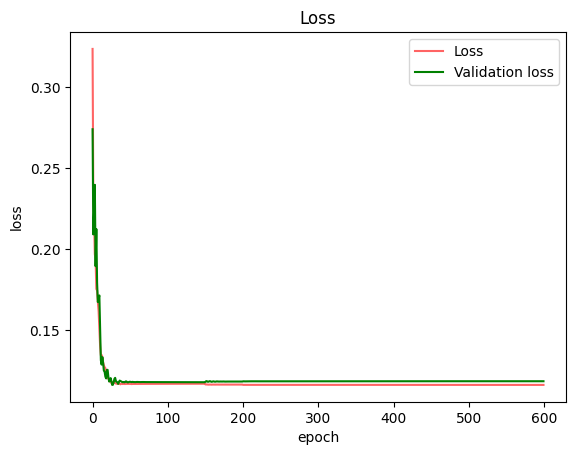

0.8865100447465779
lr: 0.15 0.15
50
step 100, accuracy_train:0.73125, loss: 0.09232775120421968
0.18691287494999517
lr: 0.15 0.15
100
0.0009369072252391532
accuracy of best loss : 0.73125
lr: 0.05 0.05
150
step 200, accuracy_train:0.7375, loss: 0.09195908771183399
0.004407720634475337
accuracy of best loss : 0.7375
lr: 0.01 0.01
200
0.001490349289315006
accuracy of best loss : 0.7375
0.01
lr: 0.001 0.001
250
step 300, accuracy_train:0.7375, loss: 0.09178710224912784
0.0003501924054735368
accuracy of best loss : 0.7375
0.01
lr: 0.0001 0.0001
300
3.692628392336729e-05
lr: 0.0001 0.0001
350
step 400, accuracy_train:0.7375, loss: 0.09178393240320126
2.9440535390993126e-07
lr: 0.0001 0.0001
400
2.8052651621190197e-07
lr: 0.0001 0.0001
450
step 500, accuracy_train:0.7375, loss: 0.09178387991673059
2.856584393010022e-07
lr: 0.0001 0.0001
500
2.9696481984027944e-07
lr: 0.0001 0.0001
550
step 600, accuracy_train:0.7375, loss: 0.09178382363021703
3.0695606634747426e-07
lr: 0.0001 0.0001
600
lr: 

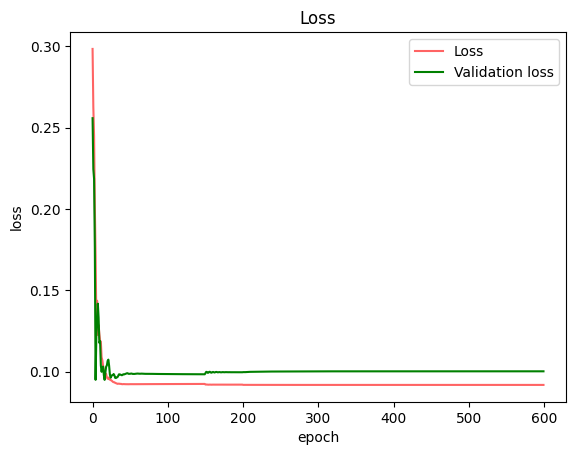

0.8353154262907037
lr: 0.15 0.15
50
step 100, accuracy_train:0.16875, loss: 0.15351596573936221
0.06818557810415057
lr: 0.15 0.15
100
0.0006658385375894393
accuracy of best loss : 0.16875
lr: 0.05 0.05
150
step 200, accuracy_train:0.16875, loss: 0.15270939647463994
0.005537021017968378
accuracy of best loss : 0.16875
lr: 0.01 0.01
200
0.0019323811057120966
accuracy of best loss : 0.16875
0.01
lr: 0.001 0.001
250
step 300, accuracy_train:0.16875, loss: 0.1523480135487914
0.0004204542524770587
accuracy of best loss : 0.16875
0.01
lr: 0.0001 0.0001
300
4.3843004478534887e-05
lr: 0.0001 0.0001
350
step 400, accuracy_train:0.16875, loss: 0.15234150312591566
1.4262701120836522e-07
lr: 0.0001 0.0001
400
1.3142245946762682e-07
lr: 0.0001 0.0001
450
step 500, accuracy_train:0.16875, loss: 0.15234146464549825
1.2620121822718022e-07
lr: 0.0001 0.0001
500
1.2262979478144075e-07
lr: 0.0001 0.0001
550
step 600, accuracy_train:0.16875, loss: 0.15234142859361582
1.1834684730231712e-07
lr: 0.0001 0.000

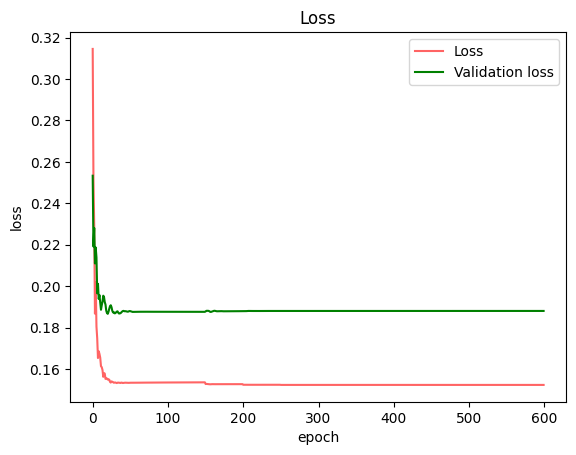

0.8992872607728238
lr: 0.15 0.15
50
step 100, accuracy_train:0.8625, loss: 0.05149863969325531
0.48703452048603874
lr: 0.15 0.15
100
0.002678043338154018
accuracy of best loss : 0.8625
lr: 0.05 0.05
150
step 200, accuracy_train:0.86875, loss: 0.05092507867308206
0.011630683308527187
accuracy of best loss : 0.86875
lr: 0.01 0.01
200
0.0033718167690099175
accuracy of best loss : 0.86875
0.01
lr: 0.001 0.001
250
step 300, accuracy_train:0.86875, loss: 0.05071779912511223
0.0006782504492368859
accuracy of best loss : 0.86875
0.01
lr: 0.0001 0.0001
300
8.912981060364113e-05
lr: 0.0001 0.0001
350
step 400, accuracy_train:0.86875, loss: 0.05071384175876116
7.529697559831341e-07
lr: 0.0001 0.0001
400
6.134336475115363e-07
lr: 0.0001 0.0001
450
step 500, accuracy_train:0.86875, loss: 0.05071378826267167
5.250611972551234e-07
lr: 0.0001 0.0001
500
4.5943340073803815e-07
lr: 0.0001 0.0001
550
step 600, accuracy_train:0.86875, loss: 0.0507137471962506
4.037781008939083e-07
lr: 0.0001 0.0001
600
lr

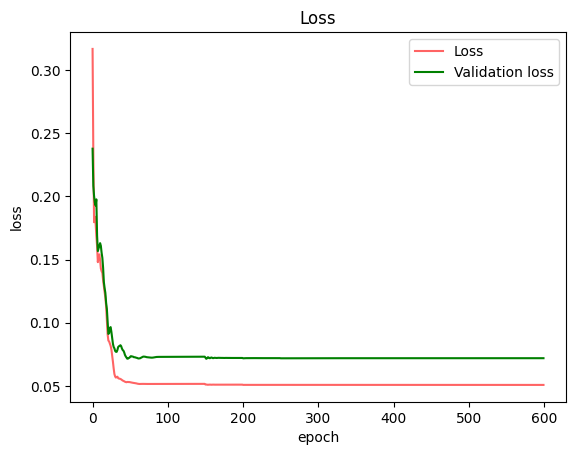

cv_time ：254.162567 s
((0.15, 0.05, 0.01, 0.001, 0.0001), 600, 100, 50, (0.05, 0.03, 0.01))
0.8947493782529365
lr: 0.15 0.15
50
step 100, accuracy_train:0.875, loss: 0.050594195557656964
0.5127748581774811
lr: 0.15 0.15
100
0.01372159163202376
accuracy of best loss : 0.88125
lr: 0.05 0.05
150
step 200, accuracy_train:0.88125, loss: 0.05057370112862103
6.685534253264837e-05
accuracy of best loss : 0.88125
lr: 0.01 0.01
200
2.685482009942472e-07
accuracy of best loss : 0.88125
0.01
lr: 0.001 0.001
250
step 300, accuracy_train:0.88125, loss: 0.05057370047556205
3.850439767377293e-09
accuracy of best loss : 0.88125
0.01
lr: 0.0001 0.0001
300
1.9523482676226858e-10
lr: 0.0001 0.0001
350
step 400, accuracy_train:0.88125, loss: 0.05057370047166792
3.8890635575230166e-11
lr: 0.0001 0.0001
400
4.1770264789041995e-11
lr: 0.0001 0.0001
450
step 500, accuracy_train:0.88125, loss: 0.05057370046717076
4.4499381651099257e-11
lr: 0.0001 0.0001
500
4.709115770725457e-11
lr: 0.0001 0.0001
550
step 600, 

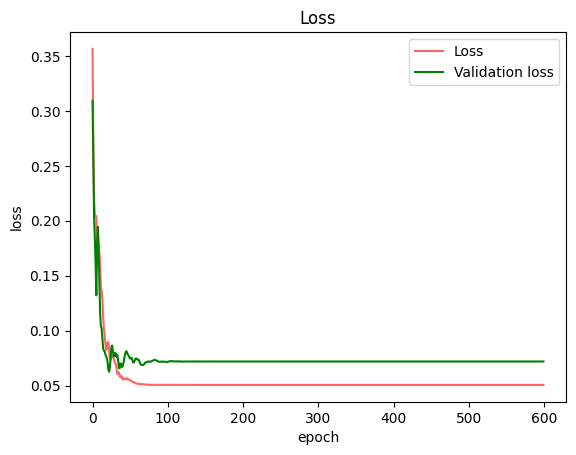

0.8306178075296091
lr: 0.15 0.15
50
step 100, accuracy_train:0.25, loss: 0.06288222784571036
0.5364033398813237
lr: 0.15 0.15
100
0.16678334722973645
lr: 0.15 0.15
150
step 200, accuracy_train:0.025, loss: 0.04518318880928553
0.1309777632295639
lr: 0.15 0.15
200
0.15317382704613886
lr: 0.15 0.15
250
step 300, accuracy_train:0.0125, loss: 0.04321392793307935
0.04092288501645436
accuracy of best loss : 0.0125
lr: 0.05 0.05
300
0.0723175997484215
lr: 0.05 0.05
350
step 400, accuracy_train:0.0, loss: 0.0418856123814916
0.0153792748110806
accuracy of best loss : 0.0
lr: 0.01 0.01
400
0.008416698206608132
accuracy of best loss : 0.0
0.01
lr: 0.001 0.001
450
step 500, accuracy_train:0.0, loss: 0.04175151717943161
0.0016153143937553999
accuracy of best loss : 0.0
0.01
lr: 0.0001 0.0001
500
0.0001724552386062747
lr: 0.0001 0.0001
550
step 600, accuracy_train:0.0, loss: 0.041748656030841574
3.461219935030258e-05
lr: 0.0001 0.0001
600
lr: 0.0001 0.0001
accuracy of best loss: 0.0 -1
Epoch:  0 | Co

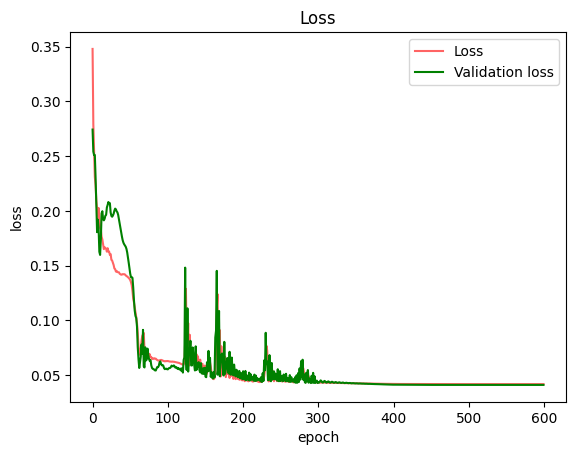

0.8960112132212004
lr: 0.15 0.15
50
step 100, accuracy_train:0.8625, loss: 0.0583278944282164
0.4354405343240913
lr: 0.15 0.15
100
0.006661696120691862
accuracy of best loss : 0.86875
lr: 0.05 0.05
150
step 200, accuracy_train:0.86875, loss: 0.05831409392924019
4.558465405100499e-05
accuracy of best loss : 0.86875
lr: 0.01 0.01
200
1.4263409930646025e-07
accuracy of best loss : 0.86875
0.01
lr: 0.001 0.001
250
step 300, accuracy_train:0.86875, loss: 0.05831409287172228
7.596120913763729e-09
accuracy of best loss : 0.86875
0.01
lr: 0.0001 0.0001
300
6.808268023316238e-10
lr: 0.0001 0.0001
350
step 400, accuracy_train:0.86875, loss: 0.058314092855724024
1.3857668006156377e-10
lr: 0.0001 0.0001
400
1.4943538800264755e-10
lr: 0.0001 0.0001
450
step 500, accuracy_train:0.86875, loss: 0.058314092837095155
1.5986179904870407e-10
lr: 0.0001 0.0001
500
1.6991659897435066e-10
lr: 0.0001 0.0001
550
step 600, accuracy_train:0.86875, loss: 0.05831409281615592
1.7965726077791208e-10
lr: 0.0001 0.000

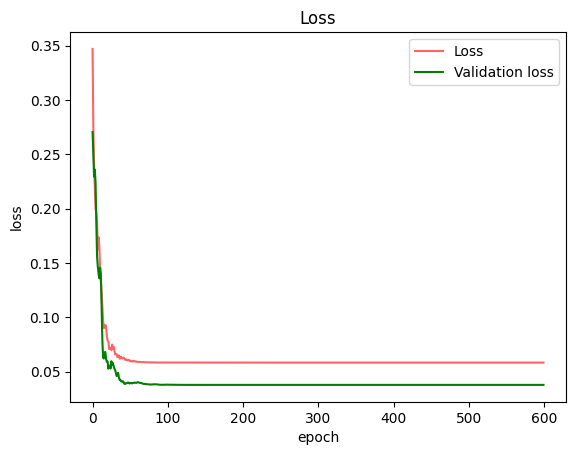

In [ ]:
# Grid search of hyper-parameters
best_h_pm, h_pm_rsts =[], []
cv_start = time.process_time()
configs['noise'] = training_noise
for setting in settings:
    enc_dim,num_qubits,num_layers,num_reupload,num_rot = setting
    X_train, y_train, X_test, y_test = initialize_data(problem,num_training,num_test,seed_num,enc_dim,**configs)
    
    h_pm_rst=[]
    loss_history_cvs=[]
    configs['qc'] = qcircuit(*setting, **configs)
    
    for h_pm in h_pms:
        learning_rate,max_epoch,batch_size,dynamic_size,threshold = h_pm
        configs['_h_pm'] = tuple(h_pm)
        
        seed_rsts, seed_params = [], []
        loss_history, valid_loss_history = [], []
        accuracy_history = []
        h_pm_rst.append(n_cv(num_cvs, X_train, y_train,setting, **configs))
        print(h_pm)

        
    h_pm_i = np.argmax(h_pm_rst,axis=0)[0]
    best_h_pm.append(h_pm_i)
    h_pm_rsts.append(h_pm_rst)
    l_h_best, val_l_h_best = loss_history_cvs[h_pm_i]
    plot_loss_history(l_h_best, val_l_h_best, setting=setting, fig_name=f'{setting}_loss_best_h_pms')
t_cvs = time.process_time()-cv_start

In [ ]:
monitor.checkpoint("After trial")
gc.collect()
monitor.checkpoint("After gc.collect()")

In [ ]:
def run(seed_num, x_tr, y_tr, *args, x_te=None, y_te=None, ratio_tr=0.875, **kwargs):
    #if:   x_te=None & y_te=None -> choosing random seed with validation accuracy
    #else: train and test
    global loss_history, valid_loss_history, lr    
    # print('run args', args)
    # configs['qc'] = qcircuit(*args, **configs)
    
    if x_te is None and y_te is None:
        from sklearn.utils import shuffle
        from sklearn.model_selection import train_test_split
        xs_tr, xs_val, ys_tr, ys_val = train_test_split(
            x_tr,y_tr,train_size=ratio_tr,random_state=seed_num,stratify=y_tr)
        # xs = shuffle(x_tr, random_state=seed_num, n_samples=None)
        # ys = shuffle(y_tr, random_state=seed_num, n_samples=None)
        # num_seed_train = int(num_training*ratio_tr)
        # num_seed_valid = num_training-num_seed_train
        # xs_tr = xs[:num_seed_train] 
        # ys_tr = ys[:num_seed_train]
        # xs_val = xs[num_seed_train:] 
        # ys_val = ys[num_seed_train:] 
    else:
        xs_tr, ys_tr, xs_val, ys_val = x_tr, y_tr, x_te, y_te

    params = initialize_params(enc_dim, num_qubits, num_layers, num_reupload, num_rot, kwargs['num_class_1q'], seed_num)
    optimizer = optax.inject_hyperparams(optax.adam)(learning_rate=lr)
    opt_state = optimizer.init(params)
    if x_te is None and y_te is None: # optimized by validation data but not peeking in true test data
        params, lr, opt_state, num_epoch = fit(params, optimizer, opt_state, xs_tr, ys_tr,x_valid=xs_val,y_valid=ys_val, *args, **kwargs)  
    else: 
        params, lr, opt_state, num_epoch = fit(params, optimizer, opt_state, xs_tr, ys_tr, *args, **configs)
    accuracy_train, loss, accuracy_valid, loss_test = scores(params, xs_tr, ys_tr, x_te=xs_val, y_te=ys_val, *args, **kwargs)
    plot_loss_history(loss_history, valid_loss_history, setting=args, fig_name=None)
    
    if x_te is None and y_te is None:
        print("Epoch: {:2d} | Cost: {:3f} | Train accuracy: {:3f} | Validation Accuracy: {:3f}".format(0, loss, accuracy_train, accuracy_valid))
    else:
        print("Epoch: {:2d} | Cost: {:3f} | Train accuracy: {:3f} | Test Accuracy: {:3f}".format(0, loss, accuracy_train, accuracy_valid))
    print(f"(n_dim, n_q, n_f, n_r, n_rot) = {enc_dim, num_qubits, num_layers, num_reupload, num_rot}")
    
    return params, [seed_num, accuracy_train, accuracy_valid, loss, num_epoch]

In [ ]:
t_seed_start = time.process_time()
configs['noise'] = training_noise
best_params = []
results = []
for i,setting in enumerate(settings):
    enc_dim,num_qubits,num_layers,num_reupload,num_rot = setting
    learning_rate,max_epoch,batch_size,dynamic_size,threshold = h_pms[best_h_pm[i]]
    t_seed_start = time.process_time()
    # Generate training and test data
    X_train, y_train, X_test, y_test = initialize_data(problem,num_training,num_test,seed_num,enc_dim,**configs)
    configs['qc'] = qcircuit(*setting, **configs)
    
    seed_rsts, seed_params = [], []
    loss_history_seeds= []
    #run 10 seeds
    for seed_num in seeds:
        #########
        loss_history = []
        valid_loss_history = []
        accuracy_history = []  
        configs['iter_lr'] = iter(learning_rate)
        configs['iter_thres'] = iter(list(threshold))
        configs['lr'] = next(configs['iter_lr'])
        configs['thres_n'] = next(configs['iter_thres'])

        seed_rst = run(seed_num, X_train, y_train, *setting, **configs)
        #########
        seed_params.append(seed_rst[0])
        seed_rsts.append(seed_rst[1])
        loss_history_seeds.append([loss_history,valid_loss_history])
    t_n_seeds = time.process_time()-t_seed_start
    print('t_n_seeds:', t_n_seeds)
    best_index = np.argmax(seed_rsts,axis=0)[2]  #best index based on validation accuracy->(seed_num,accuracy_train, accuracy_valid,...) 
    #best_rst = seed_rsts[best_index]
    seed_num = seeds[best_index]
    l_h_best, val_l_h_best = loss_history_seeds[best_index]
    plot_loss_history(l_h_best, val_l_h_best, setting=setting,
                      fig_name = f'{setting}_loss_best_seed')
    #########
    configs['noise'] = test_noise
    loss_history = []
    valid_loss_history = []
    accuracy_history = []
    configs['iter_lr'] = iter(learning_rate)
    configs['iter_thres'] = iter(list(threshold))
    configs['lr'] = next(configs['iter_lr'])
    configs['thres_n'] = next(configs['iter_thres'])
    params,best_rst = run(seed_num, X_train, y_train, x_te = X_test, y_te = y_test, ratio_tr=1, *setting, **configs)
    plot_loss_history(loss_history, setting=setting)
    #########
    best_params.append(params)
    results.append([enc_dim,num_qubits,num_layers,num_reupload,num_rot,*best_rst, t_n_seeds])
t_seeds = time.process_time()-t_seed_start

In [ ]:
def name_experiment(num_settings,start_value):
    exp_name = '('
    exp = ['enc','q','f','r','rot']
    # if len(exp)!=len(num_settings): print(experiment styles not matched!)
    for i, j in enumerate(num_settings):
        exp_name = exp_name+f'{start_value[i]}' if j==1 else exp_name+f'{exp[i]}'
        exp_name = exp_name+')' if i==len(exp)-1 else exp_name+','
    return exp_name
exp_name = name_experiment(num_settings,start_values)
exp_name

In [ ]:
import pandas as pd
data = {'enc_dim' : [],
        'num_qubits' : [],
        'num_layers' : [],
        'num_reupload' : [],
        'num_rot ': [],
        'seed_num' : [],
        'Train_acc' : [],
        'Test_acc' : [],
        'loss' : [],
        'num_epoch':[],
        f'time_{num_seeds}_seeds' : []}
for result in results:
    for i,(d,r) in enumerate(zip(data,result)):
        print(d,r)
        if i<5: data[d].append(int(r));
        else:   data[d].append(float(r))

# 将数据转换为DataFrame
df = pd.DataFrame(data)
df.style.hide()
# 显示DataFrame
#print(df.to_string(index=False))
# 若要在Jupyter Notebook中显示漂亮的表格，可以使用以下方法
display(df)
# 如果需要将DataFrame保存为HTML文件，可以使用以下方法
# df.to_html('table.html')

# Export to Excel
excel_file_path = f'Data_{exp_name}.xlsx'
sheet_name = 'Sheet1'

df.to_excel(excel_file_path, index=False, sheet_name=sheet_name)

In [ ]:
rec_settings = {'problem':problem,
                'shape':shape, 
                'rot':rot,
                'num_training':len(X_train),
                'num_test':len(X_test),
                'preprocess':configs['preprocess'],
                'max_converge_number':max_n_converge,
                'threshold_of_converge':thres_converge,
                'data_seed_num': data_seed_num,
                'param_seed_nums': seeds,
                f't_{num_cvs}_cv': f'{t_cvs} s',
                f't_{num_seeds}_seeds': f'{t_seeds} s',
                '[enc_dim,num_qubits,num_layers,num_reupload,num_rot]':settings,
                '[learning_rate,max_epoch,batch_size,dynamic_size,threshold]':[h_pms[i] for i in best_h_pm ]
               }
#dict_settings = {k:v for i,(k,v) in enumerate(data.items()) if i<6 }

In [ ]:
F = open("{}_settings.txt".format(ver), "w")
for i,j in rec_settings.items():
    F.write(i+": {}\n".format(j))
    
for i,setting in enumerate(settings):
    F.write(f"params of setting {setting}：\n")
    for key, value in best_params[i].items():
        F.write(f"    {key}: {value} \n")
F.close()

In [ ]:
print(t_cvs)
t_seeds

In [ ]:
for run_exp, x_label in zip([i != 1 for i in num_settings],data):
    if run_exp:
        fig, ax = plt.subplots(1, 1)
        ax.set_ylim([0.5, 1])
        plt.plot(data[x_label],data['Train_acc'],color=(255/255,100/255,100/255),label='Train_acc')
        plt.plot(data[x_label],data['Test_acc'],color='g',label='Test_acc')
        for i,j,k in zip(data[x_label],data['Train_acc'],data['Test_acc']):
            ax.annotate(f'{j}', xy=(i,j), xytext=(0,-10), textcoords='offset points' ,ha='center')
            ax.annotate(f'{k}', xy=(i,k), xytext=(0,-10), textcoords='offset points' ,ha='center')
        plt.title("Accuracy") # title
        plt.ylabel("accuracy") # y label
        plt.xlabel(x_label) # x label
        plt.legend()
        plt.show()
        fig.savefig(f'Accuracy-{x_label}.png', transparent=True)

In [ ]:
for i in best_h_pm:
    print(h_pms[i])
best_h_pm

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report

X_train, y_train, X_test, y_test = initialize_data(problem,num_training,num_test,seed_num,enc_dim,**configs)
max_search_n=20
n_nodes = []
t1_c = time.process_time()

r_enc, r_q ,r_f, r_r, r_rot = num_settings 

for f in range(r_f):
    scores=[]
    for n in range(max_search_n):
        size = [n+1]*(f+1)
        clf = MLPClassifier(solver='adam', alpha=1e-5,hidden_layer_sizes=size, 
                            random_state=data_seed_num,max_iter=6000, warm_start=False)
        score = np.min(cross_val_score(clf, X_train, y_train, cv=10))  
        if score >= data['Test_acc'][f] or n == (max_search_n-1): 
            n_nodes.append(n+1)
            break

sizes = [[n_nodes[f]]*(f+1) for f in range(r_f)] if r_f!=1 else [[n_nodes[f]]]*len(settings)
accuracy_tr, accuracy=[],[]

for size in sizes:
    seed_tr_rsts, seed_rsts = [], []
    for seed in seeds:
        clf = MLPClassifier(solver='adam', alpha=1e-5,hidden_layer_sizes=size, 
                                random_state=seed,max_iter=6000, warm_start=False)
        clf.fit(X_train, y_train)
        y_pred_tr = clf.predict(X_train)
        y_pred = clf.predict(X_test)
        # report = classification_report(y_test, y_pred)
        seed_tr_rsts.append(accuracy_score(y_train, y_pred_tr))
        seed_rsts.append(accuracy_score(y_test, y_pred))
    accuracy_tr.append(np.average(seed_tr_rsts))
    accuracy.append(np.average(seed_rsts))
t_c_tot = time.process_time()-t1_c
print(f'Time for classical NN: {t_c_tot} s') # Need modified  as detail version
print(accuracy_tr)
print(accuracy)
print(data['Test_acc'])
sizes

In [ ]:
def param_n_model(settings, model='NN'):
    if model=='NN':
        n_params = []
        for n_nodes in settings:
            # n_params = []
            r_f = len(n_nodes)
            for f in range(r_f):
                n_p=0
                for i in range(f+1):
                    n_p=n_p+(len(X_train[0])+1)*n_nodes[f] if i==0  else n_p
                    n_p=n_p+(n_nodes[i]+1)*num_class if i==(r_f-1) else n_p
                    n_p=n_p+(n_nodes[f]+1)*n_nodes[f] if i!=0 or i!=(r_f-1) else n_p
            n_params.append(n_p)
    if model=='QNN':
        n_params=[]
        for setting in settings:
            enc_dim,num_qubits,num_layers,num_reupload,num_rot = setting
            n_params.append((enc_dim +num_rot*3)*num_qubits*num_reupload*num_layers+ num_class* num_qubits)

    return n_params
num_params_NN = param_n_model(sizes,model='NN')
num_params_QNN = param_n_model(settings,model='QNN') 

print('Number of params in NN model:', num_params_NN)
print('Number of params in QNN model:', num_params_QNN)

In [ ]:
import pandas as pd
c_values=np.array([[str(size) for size in sizes],accuracy_tr,accuracy,data['Test_acc'],
                   num_params_NN,num_params_QNN,[t_c_tot]*len(settings)])
c_values=np.append(settings,c_values.T, axis=1)
c_data = {'enc_dim' : [],
        'num_qubits' : [],
        'num_layers' : [],
        'num_reupload' : [],
        'num_rot ': [],
        'num_c_nodes ': [],
        'C_train_acc' : [],
        'C_test_acc' : [],
        'Q_test_acc' : [],
        'num_params_NN' : [],
        'num_params_QNN' : [],
        f'time_{num_seeds}_seeds' : []}
for result in c_values:
    for i,(d,r) in enumerate(zip(c_data,result)):
        # if type(r) is np.str_: c_data[d].append(r);
        # elif i<6: c_data[d].append(int(r));
        # else:   c_data[d].append(float(r))
        if i<6: c_data[d].append(r);
        else:   c_data[d].append(float(r))


df = pd.DataFrame(c_data)
df.style.hide()
display(df)
# Export to Excel
excel_file_path = f'classical_data_comparism.xlsx'
sheet_name = 'Sheet1'
df.to_excel(excel_file_path, index=False, sheet_name=sheet_name)

In [ ]:
for fx #Stop here

In [ ]:
#Run on real device
test_noise= True
str_error = None
noise_num_Test = 100
sleep_time = 2
num_retries = 10

configs['real_device'] = True #False    #
configs['backend_name'] = 'ibm_brisbane' # None #
configs['noise'] = test_noise
configs['qc'] = qcircuit(*setting, **configs)
ver = ver+'_'+configs['backend_name'] if test_noise else ver

noise_batch_size = 9 if configs['real_device'] else noise_num_Test
noise_start = time.time()
noise_X_Test, noise_y_Test = data_gen(problem,noise_num_Test,seed_num=noise_num_Test)#circle(num_test)#
# noise_X_Test = np.hstack((np.zeros((noise_num_Test,1)), noise_XTest))
noise_predicted_Test = jnp.array([])
noise_minibatches = iterate_minibatches(noise_X_Test, noise_y_Test, batch_size=noise_batch_size)

print(configs['backend_name'],noise_start)

In [ ]:
while True:
    try: 
        if not str_error:
            Xbatch, ybatch = next(noise_minibatches)
        for x in range(0, num_retries):  
            try:
                str_error = 'Calculating...'
                predicted, loss, _  = jtest(params, Xbatch, ybatch,*setting,**configs)
                noise_predicted_Test = jnp.append(noise_predicted_Test, predicted)
                print(predicted)
                str_error = None
            except Exception as e:
                str_error = str(e)
                print('err:',str_error)
            if str_error:               # if None->break, if 'some_string'(error happens)->sleep and retry
                time.sleep(sleep_time)  # wait before trying to fetch the data again
                sleep_time *= 1.5  
                if x==(num_retries-1):
                    print('operation fail')
                else:
                    print(f'retry {x} times')
            else:
                break
    except StopIteration:
        break
noise_end = time.time()

In [ ]:
noise_accuracy_Test = accuracy_score(noise_y_Test, noise_predicted_Test)  
print("noise:",noise,", real_device:",real_device,', backend:',backend,', num_noise_Test:',noise_num_Test,file = F)#)#
print("Cost: {:3f} | Noisy Test Accuracy : {:3f}".format(loss, noise_accuracy_Test), file = F)#)#
print("process_time ：%f s" % (noise_end- noise_start), file = F)#)#
print(datetime.datetime.now(), file = F)#)#
# print('noise_model:', None if real_device else noise_model, file = F)
F.close()#
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
plot_data(X_train, y_train, fig, axes[0])
plot_data(noise_X_Test[:,1:], noise_predicted_Test, fig, axes[1])
plot_data(noise_X_Test[:,1:], noise_y_Test, fig, axes[2])
axes[0].set_title("Training data")
axes[1].set_title("Predictions after training \n Accuracy with noise = {}".format(noise_accuracy_Test))
axes[2].set_title("True test data \n # of points = {}".format(noise_num_Test))
plt.tight_layout()
plt.show()
fig.savefig('{}_noise_test.png'.format(ver), transparent=True)

In [ ]:
qml.about()

In [ ]:
a = [(i,j) for i,j in zip(globals().keys(),globals().values())]
import sys
for i,j in a:
    print(i,sys.getsizeof(j))

In [ ]:
# minimum qiskit-runtime connect-testing code

sleep_time = 5
num_retries = 5
str_error = None
initial_layout = [1,2]# None#
backend = 'ibmq_mumbai' #'ibmq_qasm_simulator' # or 
program_id = 'qiskit.ibmq.sampler' #'qiskit.ibmq.circuit_runner' # 
provider = IBMProvider(instance='ibm-q-hub-ntu/ntu-internal/default')
dev = qml.device(program_id, wires=2, backend=backend
                 , provider=provider,initial_layout=initial_layout,start_session=True)

@qml.qnode(dev)
def circuit(x, y):
    qml.RY(y, wires=[0])
    qml.RX(x, wires=[0])
    qml.CNOT(wires=[0,1])
    return qml.expval(qml.Hermitian([[1,0],[0,0]],wires=0)),qml.expval(qml.PauliY(wires=1))

data = iter([[[0.1,0.2,0.3],[0.2,0.3,0.4]],[[0.4,0.5,0.6],[0.5,0.6,0.7]]])

while True:
    try:
        if not str_error:
            databatch=next(data)
        for x in range(0, num_retries):  
            try:
                rst = circuit(*databatch)
                print('result:',rst)
                str_error = None
            except  Exception as e:
                str_error = str(e)
                print(e)
            if str_error:               # if None->break; if 'some_string'(error happens)->sleep
                time.sleep(sleep_time)  # wait before trying to fetch the data again
                sleep_time *= 3
                print(f'retry {x} times')
            else:
                break
    except StopIteration:
        break

In [ ]:
initial_layout = [1,2]#None #
backend = 'ibm_auckland'# 'ibmq_qasm_simulator' # or 
program_id = 'qiskit.ibmq.sampler' #'qiskit.ibmq.circuit_runner' # 
provider = IBMProvider(instance='ibm-q-hub-ntu/ntu-internal/default')
dev = qml.device(program_id, wires=2, backend=backend
                 , provider=provider,initial_layout=initial_layout)

@qml.qnode(dev)
def circuit(x, y):
    qml.RY(y, wires=[0])
    qml.RX(x, wires=[0])
    qml.CNOT(wires=[0,1])
    return qml.expval(qml.PauliZ(wires=0)),qml.expval(qml.PauliY(wires=1))

data = iter([[[0.1,0.2,0.3],[0.2,0.3,0.4]],[[0.4,0.5,0.6],[0.5,0.6,0.7]]])
databatch = next(data)
databatch = next(data)
circuit(*databatch)

In [ ]:
##qiskit version
from qiskit import *
from qiskit.compiler import transpile, assemble
from qiskit_ibm_runtime import QiskitRuntimeService, Session, Sampler, Estimator, Options

shots = 2048
sleep_time = 5
num_retries = 5
str_error = None
initial_layout = None#[1,2]
provider = IBMProvider(instance='ibm-q-hub-ntu/ntu-internal/default')
backend = provider.get_backend('ibmq_jakarta')#'ibm_hanoi')#'ibmq_qasm_simulator')#'ibmq_quito')
runtime_service = QiskitRuntimeService(channel="ibm_quantum")
options = {"backend": backend.name}
def qcircuit(x,y):
    qr = QuantumRegister(2)
    cr = ClassicalRegister(2)
    circuit = QuantumCircuit(qr, cr)
    circuit.rx(x,qr[0])
    circuit.ry(y,qr[1])
    circuit.cx(qr[0], qr[1])
    circuit.measure(qr, cr)
    mapped_circuit = transpile(circuit, backend=backend)
    return mapped_circuit
data = iter([[0.1,0.2],[0.2,0.3],[0.4,0.5]])

while True:
    try:
        if not str_error:
            databatch=next(data)
        for x in range(0, num_retries):  
            try:
                program_inputs = {"circuits": qcircuit(*databatch)  , "shots": shots , 'initial_layout':initial_layout
                                  , 'optimization_level': 3,'start_session': True}
                job = runtime_service.run(program_id="circuit-runner", options=options, inputs=program_inputs)#
                counts = job.result().get_counts()
                print('result:',counts)
                str_error = None
            except  Exception as e:
                str_error = str(e)
                print(e)
            if str_error:               # if None->break; if 'some_string'(error happens)->sleep
                time.sleep(sleep_time)  # wait before trying to fetch the data again
                sleep_time *= 3
                print(f'retry {x} times')
            else:
                break
    except StopIteration:
        break